In [1]:
import numpy as np

# The same GPT-2 output distribution p(w | "Hello world, nice to") from above, top 10 of 50257 words
# (renormalized so this top-10 slice sums to 1)
vocab = ["see", "meet", "hear", "have", "be", "know", "you", "talk", "say", "get"]
probs = np.array([0.387361, 0.154993, 0.152304, 0.127857, 0.057572, 0.043027, 0.039115, 0.015646, 0.013935, 0.008190])

print("Asking GPT-2 what is p(w|Hello world, nice to):")
for i in np.argsort(-probs):
    print(f"{vocab[i]} : {probs[i]:.4f}")
print(f"Total sum of p(w|Hello world, nice to): {probs.sum():.4f}")

Asking GPT-2 what is p(w|Hello world, nice to):
see : 0.3874
meet : 0.1550
hear : 0.1523
have : 0.1279
be : 0.0576
know : 0.0430
you : 0.0391
talk : 0.0156
say : 0.0139
get : 0.0082
Total sum of p(w|Hello world, nice to): 1.0000


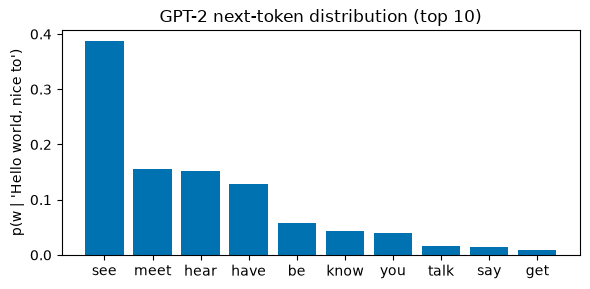

In [2]:
import matplotlib.pyplot as plt

order = np.argsort(-probs)
plt.figure(figsize=(6, 3))
plt.bar([vocab[i] for i in order], probs[order], color="#0072B2")
plt.ylabel("p(w | 'Hello world, nice to')")
plt.title("GPT-2 next-token distribution (top 10)")
plt.tight_layout()
plt.show()

In [3]:
rng = np.random.default_rng()

n = 10_000_000
target_e = "see"

# p must normalize to 1, so we renormalize our top-10 slice of the distribution
p = probs / probs.sum()
# draw all n samples at once, according to p(w | "Hello world, nice to")
outcomes = rng.choice(vocab, size=n, p=p)

prob_e = p[vocab.index(target_e)]
freq_e = np.mean(outcomes == target_e)
print(f"the expected probability of \"{target_e}\" is {prob_e}")
print(f"the actual frequency of \"{target_e}\" in {n} trials is {freq_e}")

the expected probability of "see" is 0.387361
the actual frequency of "see" in 10000000 trials is 0.3872915


In [4]:
print("gpt-2's output distribution is stored with an np.ndarray rather than a vanilla python list")
print(f"probs.shape {type(probs.shape)}: {probs.shape}")
print(f"probs.dtype {type(probs.dtype)}: {probs.dtype}")

gpt-2's output distribution is stored with an np.ndarray rather than a vanilla python list
probs.shape <class 'tuple'>: (10,)
probs.dtype <class 'numpy.dtypes.Float64DType'>: float64


In [5]:
print(f'0 ({vocab[0]}) -> {probs[0]}')
print(f'1 ({vocab[1]}) -> {probs[1]}')
print(f'2 ({vocab[2]}) -> {probs[2]}')

0 (see) -> 0.387361
1 (meet) -> 0.154993
2 (hear) -> 0.152304
